**In case of problems or questions, please first check the list of [Frequently Asked Questions (FAQ)](https://stardist.net/docs/faq.html).**

Please shutdown all other training/prediction notebooks before running this notebook (as those might occupy the GPU memory otherwise).

In [1]:
from __future__ import print_function, unicode_literals, absolute_import, division
import sys
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib
matplotlib.rcParams["image.interpolation"] = "None"
import matplotlib.pyplot as plt
%matplotlib inline
%config InlineBackend.figure_format = 'retina'

from tqdm import tqdm
from glob import glob
from tifffile import imread
from csbdeep.utils import Path, normalize
from csbdeep.io import save_tiff_imagej_compatible

from stardist import random_label_cmap
from stardist.models import StarDist3D

from skimage.measure import regionprops, label
from skimage import filters
from skimage.morphology import dilation, ball

np.random.seed(6)
lbl_cmap = random_label_cmap()

In [2]:
def correct_z_brightness(img, channels=[0, 2]):
    """
    Corrects brightness variation across the z-axis for selected channels.
    img: 4D array (Z, Y, X, C)
    channels: list of channel indices to correct (e.g. red=0, blue=2)
    """
    img_corr = img.copy()
    for c in channels:
        z_profile = img[..., c].mean(axis=(1, 2))  # Mean intensity for each Z-slice
        z_profile = z_profile / np.median(z_profile)  # Normalize profile
        for z in range(img.shape[0]):
            img_corr[z, ..., c] /= z_profile[z] + 1e-8  # Avoid divide-by-zero
    img_corr = np.clip(img_corr, 0, 1)  # Clip to valid range
    return img_corr


# Data

We assume that data has already been downloaded in via notebook [1_data.ipynb](1_data.ipynb).  
We now load images from the sub-folder `test` that have not been used during training.

In [238]:
files = sorted(glob("../../Images/Pnut_labeling_Edu_replicate3/Experimental/*"))
X = list(map(imread,files))
X = [np.moveaxis(x, 1, -1) for x in X] 

n_channel = 1 if X[0].ndim == 3 else X[0].shape[-1]
print(n_channel)
axis_norm = (0,1,2)   # normalize channels independently
print (axis_norm)
# axis_norm = (0,1,2,3) # normalize channels jointly
if n_channel > 1:
    print("Normalizing image channels %s." % ('jointly' if axis_norm is None or 3 in axis_norm else 'independently'))
X = [normalize(x,1,99.8,axis=axis_norm) for x in tqdm(X)]

#for img in X:
    #if img.ndim == 4 and img.shape[-1] > 1:
        #img[..., 1] = 0  # set green channel to 0

3
(0, 1, 2)
Normalizing image channels independently.


100%|██████████| 5/5 [00:01<00:00,  3.84it/s]


In [239]:
starimages = []

for i, img in enumerate(X):
    fas3= img[...,1]
    fas3= fas3[...,np.newaxis]
    dapi= img[...,2]
    dapi= dapi[...,np.newaxis]
    blank= np.zeros_like(dapi)
    img = np.concatenate((fas3, blank, dapi), axis= -1)
    starimages.append(img)

starimages[0].shape

(90, 246, 254, 3)

In [240]:
# Correct Z-brightness in red (0) and blue (2) channels
starimages = [correct_z_brightness(x, channels=[0, 2]) if x.ndim == 4 and x.shape[-1] > 1 else x for x in starimages]

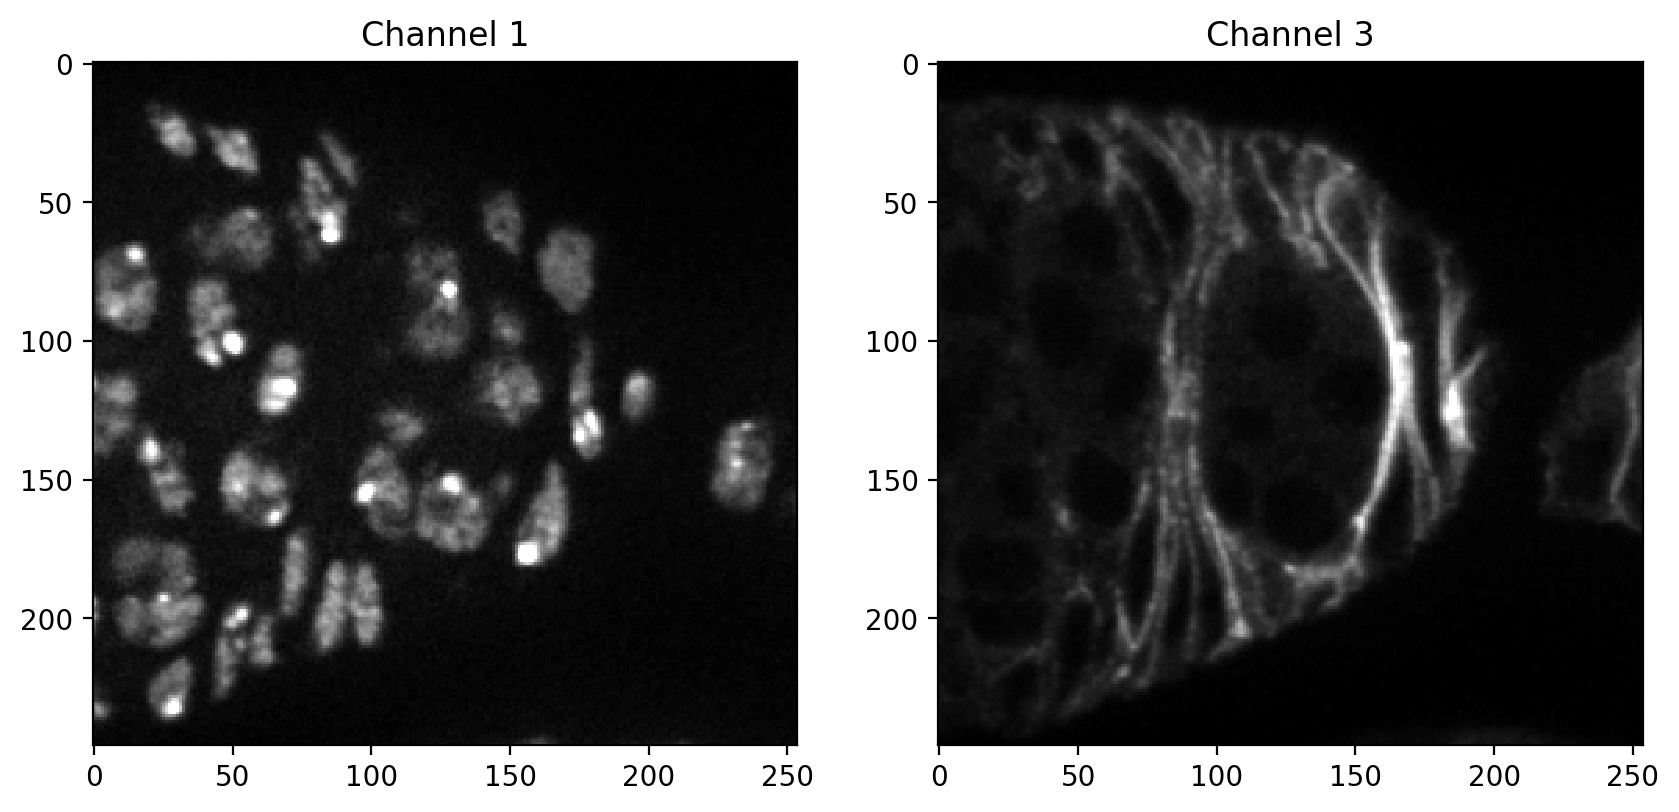

In [241]:
fig, ax = plt.subplots(1, 2, figsize=(10, 5))
ax[0].imshow(starimages[0][50, :, :, 2], cmap='gray')
ax[0].set_title('Channel 1')
ax[1].imshow(starimages[0][50, :, :, 0], cmap='gray')
ax[1].set_title('Channel 3')
plt.show()

# Load trained model

If you trained your own StarDist model (and optimized its thresholds) via notebook [2_training.ipynb](2_training.ipynb), then please set `demo_model = False` below.

In [242]:
demo_model = False

if demo_model:
    print (
        "NOTE: This is loading a previously trained demo model!\n"
        "      Please set the variable 'demo_model = False' to load your own trained model.",
        file=sys.stderr, flush=True
    )
    model = StarDist3D.from_pretrained('3D_demo')
else:
    model = StarDist3D(None, name='3D_Stardist_FINETUNED', basedir='modelsTL')
None;

Loading network weights from 'weights_best.h5'.
Loading thresholds from 'thresholds.json'.
Using default values: prob_thresh=0.468323, nms_thresh=0.3.


## Prediction

Make sure to normalize the input image beforehand or supply a `normalizer` to the prediction function.

Calling `model.predict_instances` will
- predict object probabilities and star-convex polygon distances (see `model.predict` if you want those)
- perform non-maximum suppression (with overlap threshold `nms_thresh`) for polygons above object probability threshold `prob_thresh`.
- render all remaining polygon instances in a label image
- return the label instances image and also the details (coordinates, etc.) of all remaining polygons

In [243]:
labelArray = []
mergedArray = []
detailArray = []
max_volume = 2500  # replace with your threshold

for item in starimages:
    img = normalize(item, 1, 99.8, axis=axis_norm)
    
    # Use tiling to prevent GPU OOM
    labels, details = model.predict_instances(img, prob_thresh=0.45, nms_thresh=0.3, n_tiles=(1, 2, 2, 1))  # or (1,2,2) depending on your GPU

    filtered_labels = np.zeros_like(labels)

    for region in regionprops(labels):
        if region.area <= max_volume:  # area = number of pixels/voxels
            filtered_labels[labels == region.label] = region.label
        
    detailArray.append(details)
    labelArray.append(filtered_labels)

    if img.ndim == 3:
        img = img[..., np.newaxis]

    labels_expanded = filtered_labels[..., np.newaxis]
    merged = np.concatenate((img, labels_expanded), axis=-1)
    mergedArray.append(merged)

100%|██████████| 4/4 [00:01<00:00,  2.99it/s]


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.0..1.4926299].


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.0..1.4926299].


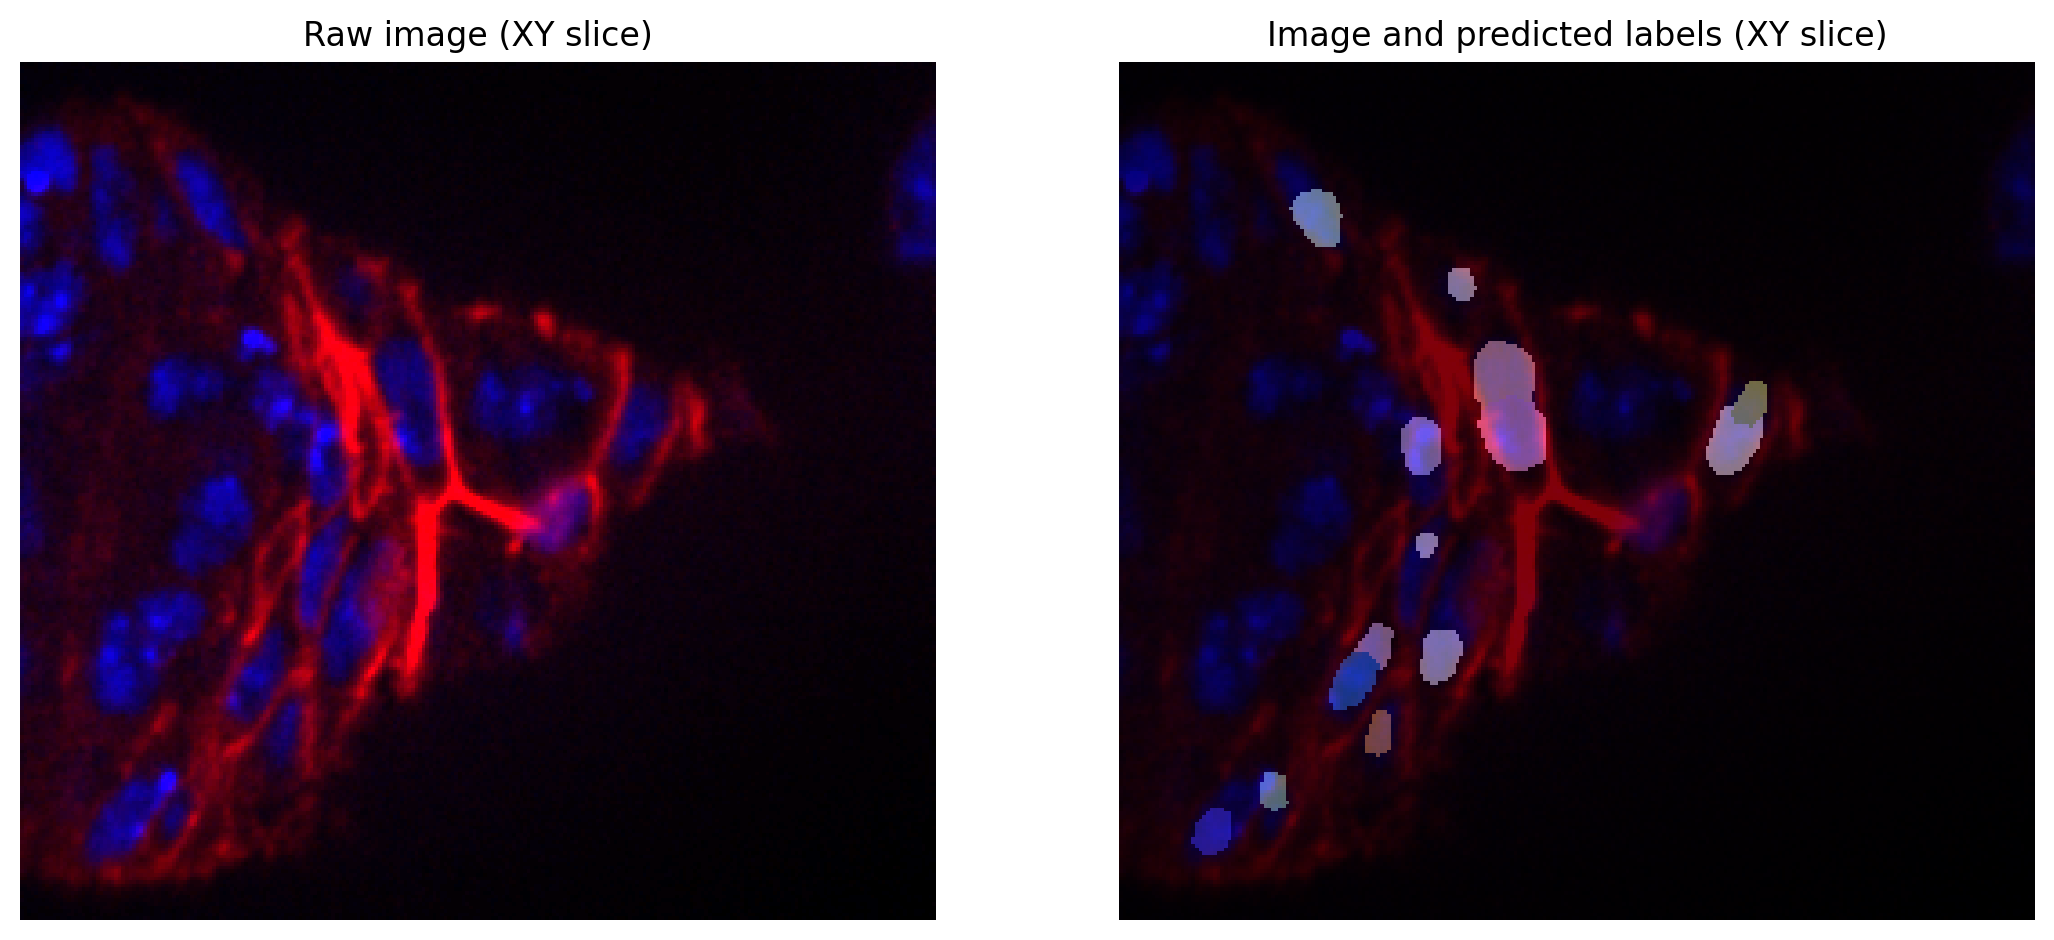

In [244]:
plt.figure(figsize=(13,10))
z = max(0, img.shape[0]//2+25)
plt.subplot(121)
plt.imshow((img if img.ndim==3 else img[...,:3])[z], clim=(0,1), cmap='gray')
plt.title('Raw image (XY slice)')
plt.axis('off')
plt.subplot(122)
plt.imshow((img if img.ndim==3 else img[...,:3])[z], clim=(0,1), cmap='gray')
plt.imshow(labels[z], cmap=lbl_cmap, alpha=0.5)
plt.title('Image and predicted labels (XY slice)')
plt.axis('off');

## Save predictions

Uncomment the lines in the following cell if you want to save the example image and the predicted label image to disk.

In [245]:
data_directory = Path('../../Images/Pnut_labeling_Edu_replicate3/Results')
# save_tiff_imagej_compatible('example_image.tif', img, axes='ZYX')
for i, img in enumerate(mergedArray):
    file_name = Path(files[i]).stem + '_wlabel.tif'
    save_tiff_imagej_compatible(data_directory / file_name, img, axes='ZYXC')

__init__.py (43): Converting data type from 'float64' to ImageJ-compatible 'float32'.


## EdU Segmentation

The following code is to reintroduce the EdU channel to the file, and do a binary detection of EdU signal.

In [246]:
unprocessed_img = list(map(imread, files))
unprocessed_img = [np.moveaxis(x, 1, -1) for x in unprocessed_img]

print("Raw shape:", unprocessed_img[0].shape)
print("Label shape:", labelArray[0].shape)

Raw shape: (90, 246, 254, 3)
Label shape: (90, 246, 254)


In [247]:
fraction_thresh = 0.1 # fraction of pixels above threshold
img_data = [] 
positive_masks = []
negative_masks = []
dilated_labels_all = []   # <--- keep track of dilated label images

for i, (raw_img, labels) in enumerate(zip(unprocessed_img, labelArray)):
    # EdU = channel 0 in raw_img
    EdU = raw_img[..., 0]

    # Otsu threshold on EdU
    EdU_otsu = filters.threshold_otsu(EdU)
    EdU_mask = EdU > EdU_otsu * 1.2   # adjust factor if needed

    # Dilate labels (use consistently everywhere)
    labels_dil = dilation(labels, ball(1))
    dilated_labels_all.append(labels_dil)

    # Create empty masks
    pos_mask = np.zeros_like(labels_dil, dtype=np.uint16)
    neg_mask = np.zeros_like(labels_dil, dtype=np.uint16)

# This is the function that defines what labels are positive vs negative 
    for prop in regionprops(labels_dil, intensity_image=EdU):
        label_id = prop.label
        prop_mask = EdU_mask[labels_dil == label_id]
        positive = np.mean(prop_mask) >= fraction_thresh # Fraction-of-pixels rule

        # Save stats
        img_data.append({
            'Genotype': 'Control',
            'Sample': str(i),
            'label': label_id,
            'area': prop.area,
            'EdU_mean': prop.mean_intensity,
            'EdU_total': prop.mean_intensity * prop.area,
            'EdU_positive': positive
        })

        # Build masks
        if positive:
            pos_mask[labels_dil == label_id] = label_id
        else:
            neg_mask[labels_dil == label_id] = label_id

    positive_masks.append(pos_mask)
    negative_masks.append(neg_mask)

# Convert stats to DataFrame
img_data = pd.DataFrame(img_data)


In [248]:
# Count positives/negatives
total_cells = len(img_data)
num_pos = img_data['EdU_positive'].sum()
num_neg = total_cells - num_pos

print(f"Total cells: {total_cells}")
print(f"EdU-positive: {num_pos} ({num_pos/total_cells*100:.1f}%)")
print(f"EdU-negative: {num_neg} ({num_neg/total_cells*100:.1f}%)")

summary = (
    img_data
    .groupby("Sample")["EdU_positive"]
    .agg(
        total_cells="count",
        num_pos="sum"
    )
)
summary["num_neg"] = summary["total_cells"] - summary["num_pos"]
summary["percent_pos"] = summary["num_pos"] / summary["total_cells"] * 100

print(summary)

Total cells: 292
EdU-positive: 52 (17.8%)
EdU-negative: 240 (82.2%)
        total_cells  num_pos  num_neg  percent_pos
Sample                                            
0                66       12       54    18.181818
1                45       14       31    31.111111
2                50        6       44    12.000000
3                72       11       61    15.277778
4                59        9       50    15.254237


In [249]:
# Save TIFFs with unprocessed images (3 channels) + 2 masks
data_directory = Path('../../Images/Pnut_labeling_Edu_replicate3/Results/Edu')

for i, (raw_img, labels, pos_mask) in enumerate(zip(unprocessed_img, labelArray, positive_masks)):
    # Ensure raw_img has shape (Z, Y, X, C)
    if raw_img.ndim == 3:
        raw_img = raw_img[..., np.newaxis]

    # Add masks as channels
    follicle = labels[..., np.newaxis].astype(np.uint16)
    positive = pos_mask[..., np.newaxis].astype(np.uint16)

    # Concatenate into (Z, Y, X, 5)
    final_img = np.concatenate((raw_img, follicle, positive), axis=-1)

    # Save TIFF
    file_name = Path(files[i]).stem + '_5ch_wmasks.tif'
    save_tiff_imagej_compatible(data_directory / file_name, final_img, axes='ZYXC')


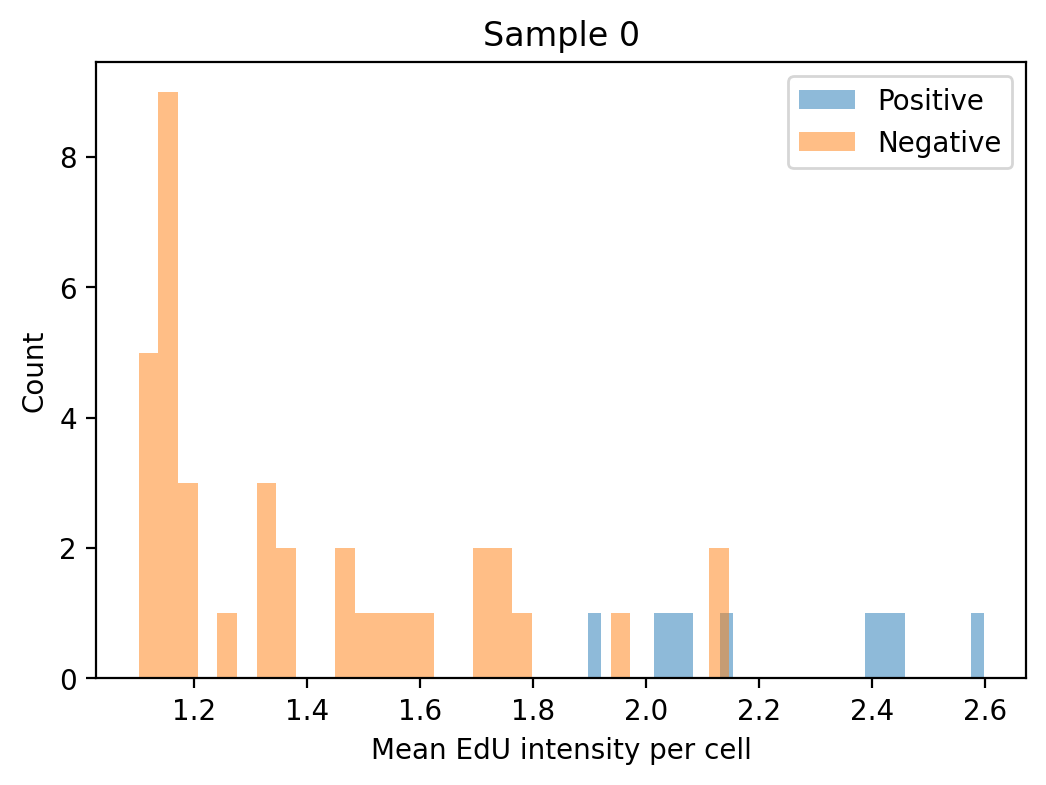

In [42]:
# Loop over each sample separately
for sample_id, df_sub in img_data.groupby("Sample"):
    pos_mean = df_sub.loc[df_sub['EdU_positive'], 'EdU_mean']
    neg_mean = df_sub.loc[~df_sub['EdU_positive'], 'EdU_mean']

    plt.figure(figsize=(6,4))
    plt.hist(pos_mean, bins=30, alpha=0.5, label='Positive')
    plt.hist(neg_mean, bins=30, alpha=0.5, label='Negative')
    plt.xlabel('Mean EdU intensity per cell')
    plt.ylabel('Count')
    plt.title(f'Sample {sample_id}')
    plt.legend()
    plt.show()


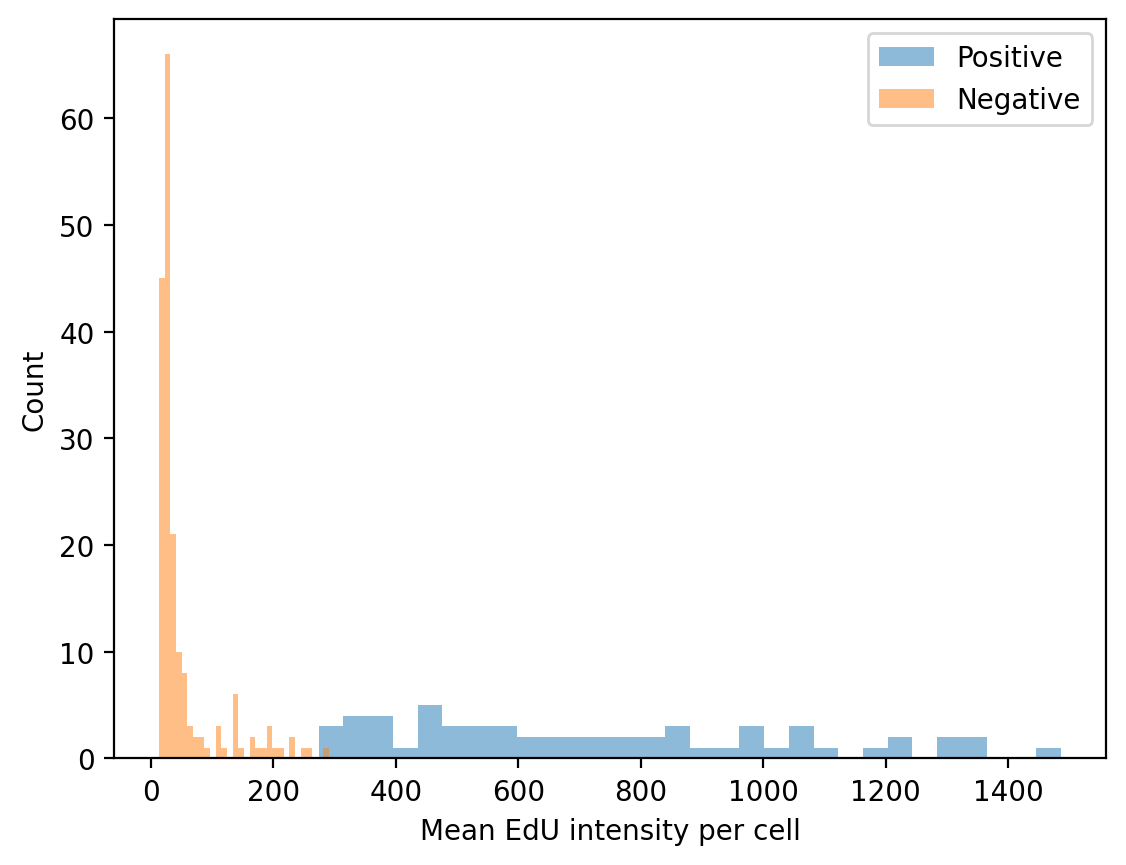

In [16]:
pos_mean = img_data.loc[img_data['EdU_positive'], 'EdU_mean']
neg_mean = img_data.loc[~img_data['EdU_positive'], 'EdU_mean']

import matplotlib.pyplot as plt

plt.hist(pos_mean, bins=30, alpha=0.5, label='Positive')
plt.hist(neg_mean, bins=30, alpha=0.5, label='Negative')
plt.xlabel('Mean EdU intensity per cell')
plt.ylabel('Count')
plt.legend()
plt.show()

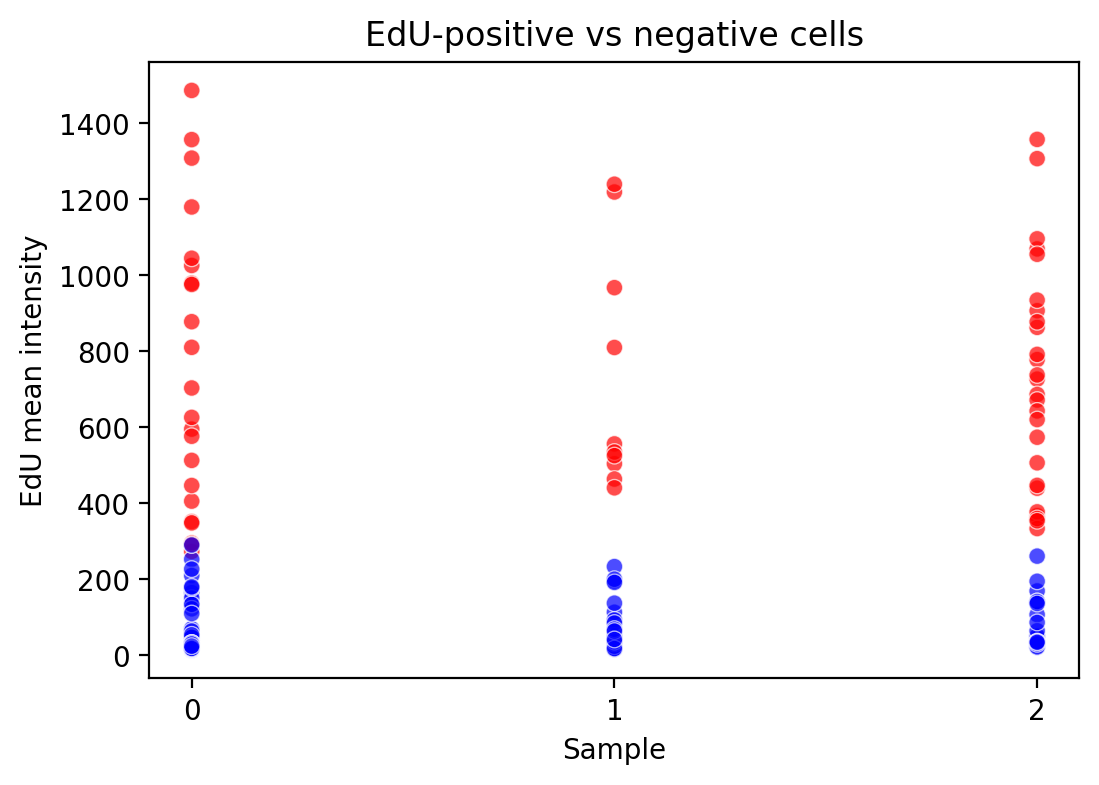

In [17]:
plt.figure(figsize=(6,4))
sns.scatterplot(
    data=img_data,
    x='Sample',
    y='EdU_mean',
    hue='EdU_positive',
    legend= False,
    palette={True: 'red', False: 'blue'},
    alpha=0.7
)
plt.xlabel('Sample')
plt.ylabel('EdU mean intensity')
plt.title('EdU-positive vs negative cells')
#plt.legend(title='EdU positive')
plt.show()


**In case of problems or questions, please first check the list of [Frequently Asked Questions (FAQ)](https://stardist.net/docs/faq.html).**

Please shutdown all other training/prediction notebooks before running this notebook (as those might occupy the GPU memory otherwise).
from __future__ import print_function, unicode_literals, absolute_import, division
import sys
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib
matplotlib.rcParams["image.interpolation"] = "None"
import matplotlib.pyplot as plt
%matplotlib inline
%config InlineBackend.figure_format = 'retina'

from tqdm import tqdm
from glob import glob
from tifffile import imread
from csbdeep.utils import Path, normalize
from csbdeep.io import save_tiff_imagej_compatible

from stardist import random_label_cmap
from stardist.models import StarDist3D

from skimage.measure import regionprops, label
from skimage import filters
from skimage.morphology import dilation, ball

np.random.seed(6)
lbl_cmap = random_label_cmap()
def correct_z_brightness(img, channels=[0, 2]):
    """
    Corrects brightness variation across the z-axis for selected channels.
    img: 4D array (Z, Y, X, C)
    channels: list of channel indices to correct (e.g. red=0, blue=2)
    """
    img_corr = img.copy()
    for c in channels:
        z_profile = img[..., c].mean(axis=(1, 2))  # Mean intensity for each Z-slice
        z_profile = z_profile / np.median(z_profile)  # Normalize profile
        for z in range(img.shape[0]):
            img_corr[z, ..., c] /= z_profile[z] + 1e-8  # Avoid divide-by-zero
    img_corr = np.clip(img_corr, 0, 1)  # Clip to valid range
    return img_corr

# Data

We assume that data has already been downloaded in via notebook [1_data.ipynb](1_data.ipynb).  
We now load images from the sub-folder `test` that have not been used during training.
files = sorted(glob("/Users/rhiannonredbird/Documents/Repository/foxtfs/Images/22RB/Con/*.tif"))
X = list(map(imread,files))
X = [np.moveaxis(x, 1, -1) for x in X] 

n_channel = 1 if X[0].ndim == 3 else X[0].shape[-1]
print(n_channel)
axis_norm = (0,1,2)   # normalize channels independently
print (axis_norm)
# axis_norm = (0,1,2,3) # normalize channels jointly
if n_channel > 1:
    print("Normalizing image channels %s." % ('jointly' if axis_norm is None or 3 in axis_norm else 'independently'))
X = [normalize(x,1,99.8,axis=axis_norm) for x in tqdm(X)]

#for img in X:
    #if img.ndim == 4 and img.shape[-1] > 1:
        #img[..., 1] = 0  # set green channel to 0
starimages = []

for i, img in enumerate(X):
    fas3= img[...,1]
    fas3= fas3[...,np.newaxis]
    dapi= img[...,2]
    dapi= dapi[...,np.newaxis]
    blank= np.zeros_like(dapi)
    img = np.concatenate((fas3, blank, dapi), axis= -1)
    starimages.append(img)
starimages[0].shape
# Correct Z-brightness in red (0) and blue (2) channels
starimages = [correct_z_brightness(x, channels=[0, 2]) if x.ndim == 4 and x.shape[-1] > 1 else x for x in starimages]

fig, ax = plt.subplots(1, 2, figsize=(10, 5))
ax[0].imshow(starimages[0][50, :, :, 2], cmap='gray')
ax[0].set_title('Channel 1')
ax[1].imshow(starimages[0][50, :, :, 0], cmap='gray')
ax[1].set_title('Channel 3')
plt.show()
# Load trained model

If you trained your own StarDist model (and optimized its thresholds) via notebook [2_training.ipynb](2_training.ipynb), then please set `demo_model = False` below.
demo_model = False

if demo_model:
    print (
        "NOTE: This is loading a previously trained demo model!\n"
        "      Please set the variable 'demo_model = False' to load your own trained model.",
        file=sys.stderr, flush=True
    )
    model = StarDist3D.from_pretrained('3D_demo')
else:
    model = StarDist3D(None, name='3D_Stardist_FINETUNED', basedir='modelsTL')
None;
## Prediction

Make sure to normalize the input image beforehand or supply a `normalizer` to the prediction function.

Calling `model.predict_instances` will
- predict object probabilities and star-convex polygon distances (see `model.predict` if you want those)
- perform non-maximum suppression (with overlap threshold `nms_thresh`) for polygons above object probability threshold `prob_thresh`.
- render all remaining polygon instances in a label image
- return the label instances image and also the details (coordinates, etc.) of all remaining polygons
labelArray = []
mergedArray = []
detailArray = []
max_volume = 2500  # replace with your threshold

for item in starimages:
    img = normalize(item, 1, 99.8, axis=axis_norm)
    
    # Use tiling to prevent GPU OOM
    labels, details = model.predict_instances(img, prob_thresh=0.35, nms_thresh=0.05, n_tiles=(1, 2, 2, 1))  # or (1,2,2) depending on your GPU

    filtered_labels = np.zeros_like(labels)

    for region in regionprops(labels):
        if region.area <= max_volume:  # area = number of pixels/voxels
            filtered_labels[labels == region.label] = region.label
        
    detailArray.append(details)
    labelArray.append(filtered_labels)

    if img.ndim == 3:
        img = img[..., np.newaxis]

    labels_expanded = filtered_labels[..., np.newaxis]
    merged = np.concatenate((img, labels_expanded), axis=-1)
    mergedArray.append(merged)


plt.figure(figsize=(13,10))
z = max(0, img.shape[0] // 2 - 5)
plt.subplot(121)
plt.imshow((img if img.ndim==3 else img[...,:3])[z], clim=(0,1), cmap='gray')
plt.title('Raw image (XY slice)')
plt.axis('off')
plt.subplot(122)
plt.imshow((img if img.ndim==3 else img[...,:3])[z], clim=(0,1), cmap='gray')
plt.imshow(labels[z], cmap=lbl_cmap, alpha=0.5)
plt.title('Image and predicted labels (XY slice)')
plt.axis('off');
## Save predictions

Uncomment the lines in the following cell if you want to save the example image and the predicted label image to disk.
data_directory = Path('../../Images/22RB/Con')
# save_tiff_imagej_compatible('example_image.tif', img, axes='ZYX')
for i, img in enumerate(mergedArray):
    file_name = Path(files[i]).stem + '_wlabel.tif'
    save_tiff_imagej_compatible(data_directory / file_name, img, axes='ZYXC')
#def subtract_background(image, background):
    #dtype = image.dtype
    #result = image.astype(np.float32) - background
    #max_val = np.finfo(dtype).max if np.issubdtype(dtype, np.floating) else np.iinfo(dtype).max
    #return np.clip(result, 0, max_val).astype(dtype)

print(unprocessed_img[0].shape)
print(labelArray[0].shape)
fraction_thresh = 0.1  # fraction of pixels above threshold
img_data = []
positive_masks = []
negative_masks = []

for i, (img, labels) in enumerate(zip(unprocessed_img, labelArray)):
    EdU = img[..., 1]
    EdU_otsu = filters.threshold_otsu(EdU)
    EdU_mask = EdU > EdU_otsu * 1.2
    labels = dilation(labels, ball(1))
    # Create empty masks for this image
    pos_mask = np.zeros_like(labels, dtype=np.uint16)
    neg_mask = np.zeros_like(labels, dtype=np.uint16)

    for prop in regionprops(labels, intensity_image=EdU):
        label_id = prop.label
        prop_mask = EdU_mask[labels == label_id]

        # Fraction-of-pixels rule
        positive = np.mean(prop_mask) >= fraction_thresh

        # Store stats in dataframe
        img_data.append({
            'Genotype': 'Control',
            'Sample': str(i),
            'label': label_id,
            'area': prop.area,
            'EdU_mean': prop.mean_intensity,
            'EdU_total': prop.mean_intensity * prop.area,
            'EdU_positive': positive
        })

        # Build masks
        if positive:
            pos_mask[labels == label_id] = label_id
        else:
            neg_mask[labels == label_id] = label_id

    positive_masks.append(pos_mask)
    negative_masks.append(neg_mask)

# Convert to DataFrame at the end
img_data = pd.DataFrame(img_data)



